# Case study I — an *E. coli* succinate cell factory

Succinate is one of the US-DOE "top-12" bio-based platform chemicals (a precursor to biodegradable plastics, solvents and food additives), and engineering *E. coli* to overproduce it is a textbook metabolic-engineering problem. The classic strategy (Millard 1996; Vemuri 2002; Sánchez 2005) is: **grow anaerobically and delete the competing fermentation routes** so carbon is forced through PEP carboxylase / fumarate reductase to succinate.

This case runs that project end-to-end with `ov.synbio` on the real `e_coli_core` genome-scale model — from *diagnosis* → *design* → *thermodynamic check* → *the enzyme that carries the flux* → *the DNA to build it*.

```bash
pip install 'omicverse[synbio]'
```

In [1]:
import omicverse as ov
ov.plot_set()
m = ov.synbio.load_gem('e_coli_core')          # real BiGG genome-scale model
print(m.id, '|', len(m.reactions), 'reactions,', len(m.genes), 'genes')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the Cobrapy repository.


INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the BiGG Models repository.


Output()

INFO:httpx:HTTP Request: GET http://bigg.ucsd.edu/static/models/e_coli_core.xml.gz "HTTP/1.1 200 OK"


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


e_coli_core | 95 reactions, 137 genes


## 1 — Diagnosis: wild-type *E. coli* barely secretes succinate

On aerobic glucose the cell maximises growth and makes almost no succinate. The **production envelope** shows the growth-vs-succinate trade-off: at the wild-type growth optimum, succinate flux is ~0.

INFO:cobra.medium.boundary_types:Compartment `e` sounds like an external compartment. Using this one without counting boundary reactions.


WT aerobic growth: 0.874 /h


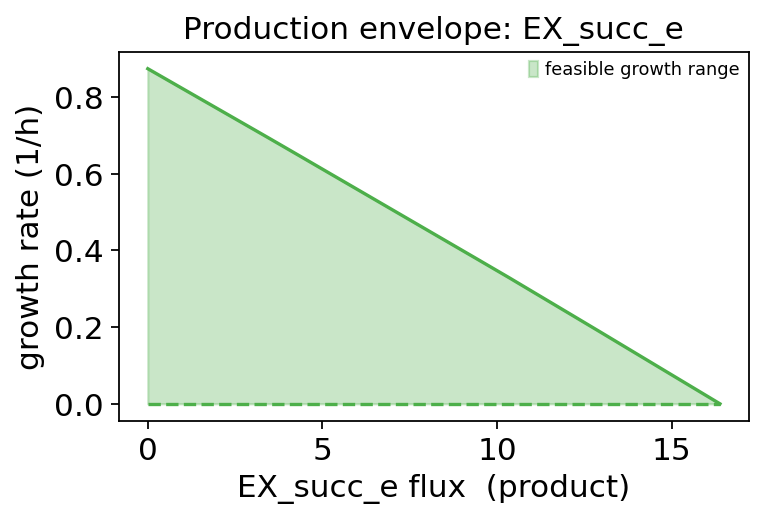

In [2]:
print('WT aerobic growth:', round(ov.synbio.fba(m).objective_value, 3), '/h')
ov.synbio.plot_production_envelope(m, 'EX_succ_e')
None

## 2 — The real strategy: go anaerobic, then knock out the competition

Cut off oxygen (`EX_o2_e` lower bound = 0). Now fermentation dominates, and `strain_design` proposes the engineering targets. **FSEOF** ranks over-expression targets — the enzymes that must carry more flux to make succinate; **OptKnock** (exact bilevel MILP via StrainDesign) proposes gene deletions that *couple* succinate to growth.

In [3]:
m_an = ov.synbio.load_gem('e_coli_core')
m_an.reactions.EX_o2_e.lower_bound = 0                       # anaerobic
sd = ov.synbio.strain_design(m_an, 'EX_succ_e', method='fseof')
print('over-express (FSEOF):', list(sd.amplify['reaction'].head(5)))
print('growth-coupled knockouts:', list(sd.knockout['reaction'].head(5)))

INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the Cobrapy repository.


INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the BiGG Models repository.


INFO:httpx:HTTP Request: GET http://bigg.ucsd.edu/static/models/e_coli_core.xml.gz "HTTP/1.1 200 OK"


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


over-express (FSEOF): ['MDH', 'FRD7', 'SUCCt3', 'FUM', 'NADH16']
growth-coupled knockouts: ['PFL', 'FORt']


The over-expression hits — **PPC** (PEP carboxylase), **FRD7** (fumarate reductase), **FUM** (fumarase), **MDH** (malate dehydrogenase) — are exactly the reductive-TCA enzymes that make succinate, and the knockouts hit **PFL** (pyruvate formate-lyase) and lactate/acetate routes — the real *pflB* / *ldhA* deletion strategy. Now confirm with the rigorous MILP:

In [4]:
ok = ov.synbio.strain_design(m_an, 'EX_succ_e', method='optknock',
                             max_knockouts=3, time_limit=120)
print('exact OptKnock knockout designs:')
ok.knockout.head()

exact OptKnock knockout designs:


,knockouts,n_knockouts
0,[GLNS],1
1,[ICDHyr],1
2,[RPI],1
3,[EX_nh4_e],1
4,[NH4t],1


## 3 — Verify the design: does succinate actually go up?

Apply a designed knockout to the anaerobic model and re-solve: knocking out pyruvate formate-lyase (`PFL`) forces carbon toward succinate — the guaranteed (growth-coupled) succinate flux rises from ~0.

In [5]:
import numpy as np
def coupled_succ(model):
    g = ov.synbio.fba(model).objective_value
    with model as mm:
        bm = [r for r in mm.reactions if r.objective_coefficient != 0][0]
        bm.lower_bound = 0.99 * g
        mm.objective = 'EX_succ_e'; mm.objective.direction = 'min'
        return ov.synbio.fba(mm).objective_value, g

s0, g0 = coupled_succ(m_an)
with m_an as mko:
    mko.reactions.PFL.knock_out()
    s1, g1 = coupled_succ(mko)
print(f'anaerobic WT : succinate {s0:.2f}  (growth {g0:.2f})')
print(f'ΔPFL strain  : succinate {s1:.2f}  (growth {g1:.2f})')

anaerobic WT : succinate 0.00  (growth 0.21)
ΔPFL strain  : succinate 0.67  (growth 0.18)


## 4 — Is the pathway thermodynamically feasible?

A design is only useful if the thermodynamics allow it. `reaction_dg(method='equilibrator')` gives real component-contribution ΔG'° (Noor 2013); `max_min_driving_force` then finds the concentration-optimised driving force of the *weakest* step of the reductive branch (PEP → OAA → malate → fumarate → succinate).

reductive-TCA ΔG'° (kJ/mol): {'PPC': -40.3, 'MDH': -26.5, 'FUM': 3.4}
MDF = 14.51 kJ/mol | feasible: True | bottleneck: MDH


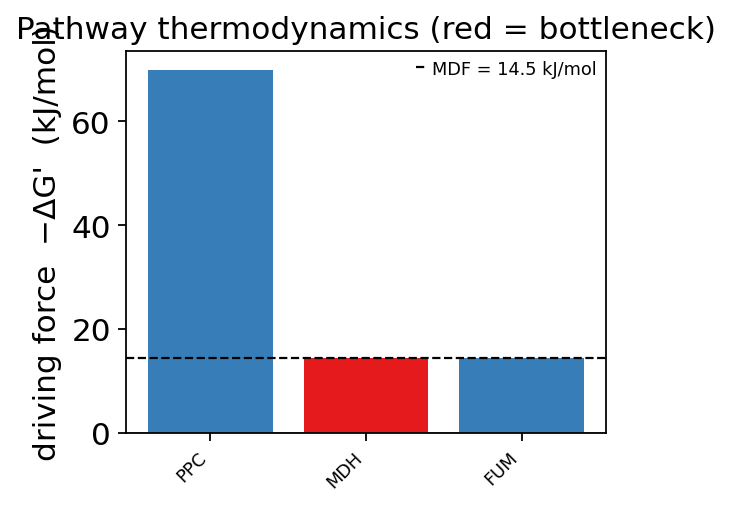

In [6]:
route = {
    'PPC': {'pep': -1, 'co2': -1, 'h2o': -1, 'oaa': 1, 'pi': 1, 'h': 1},
    'MDH': {'oaa': -1, 'nadh': -1, 'h': -1, 'mal__L': 1, 'nad': 1},
    'FUM': {'mal__L': -1, 'fum': 1, 'h2o': 1},
}
dg0 = {r: ov.synbio.reaction_dg(s, method='equilibrator') for r, s in route.items()}
mdf = ov.synbio.max_min_driving_force(route, dg0, fixed={'h': 1e-7, 'h2o': 1, 'co2': 1e-4})
print('reductive-TCA ΔG\'° (kJ/mol):', {r: round(v, 1) for r, v in dg0.items()})
print('MDF =', round(mdf.mdf, 2), 'kJ/mol | feasible:', mdf.feasible, '| bottleneck:', mdf.bottleneck)
ov.synbio.plot_driving_forces(mdf)
None

## 5 — The enzyme that carries the flux → back to the model

PEP carboxylase (**Ppc**) is the entry enzyme of the succinate branch. Its turnover number sets how much protein the cell must invest to carry that flux. Predict `k_cat` for Ppc with **DLKcat** (real trained model) on its substrate PEP, push it into an enzyme-constrained model, and see the growth cost — the A↔B hinge.

In [7]:
# real E. coli PEP carboxylase (Ppc) N-terminal fragment + its substrate PEP
PPC = ('MNEQYSALRSNVSMLGKVLGETIKDALGEHILERVETIRKLSKSSRAGNDANRQELLTTLQNLSNDELLPVARAFSQFL'
       'NLANTAEQYHSISPKGEAASNPEVIARTLRKLKNQPELSEDTIKKAVESLSLELVLTAHPTEITRRTLIHKMVEVNACL')
PEP = 'C(=C(/[O-])COP(=O)([O-])[O-])/C(=O)[O-]'
k = ov.synbio.enzyme_kcat(PPC, PEP, method='dlkcat', verbose=False)
print('DLKcat k_cat(Ppc, PEP) =', round(k.kcat, 3), '/s')
ecm = ov.synbio.ec_model(m, {'PPC': k.kcat})
print('growth with Ppc enzyme-constrained:', round(ov.synbio.fba(ecm).objective_value, 3), '/h')

DLKcat k_cat(Ppc, PEP) = 0.835 /s


growth with Ppc enzyme-constrained: 0.489 /h


## 6 — Build it: codon-optimize the over-expression target + primers

To over-express Ppc you order a synthetic, host-optimised gene and the primers to clone it. `codon_optimize` rewrites it for *E. coli* codon usage (GC-bounded, restriction-site-free); `design_primers` returns validated PCR pairs.

expression cassette: 556 bp


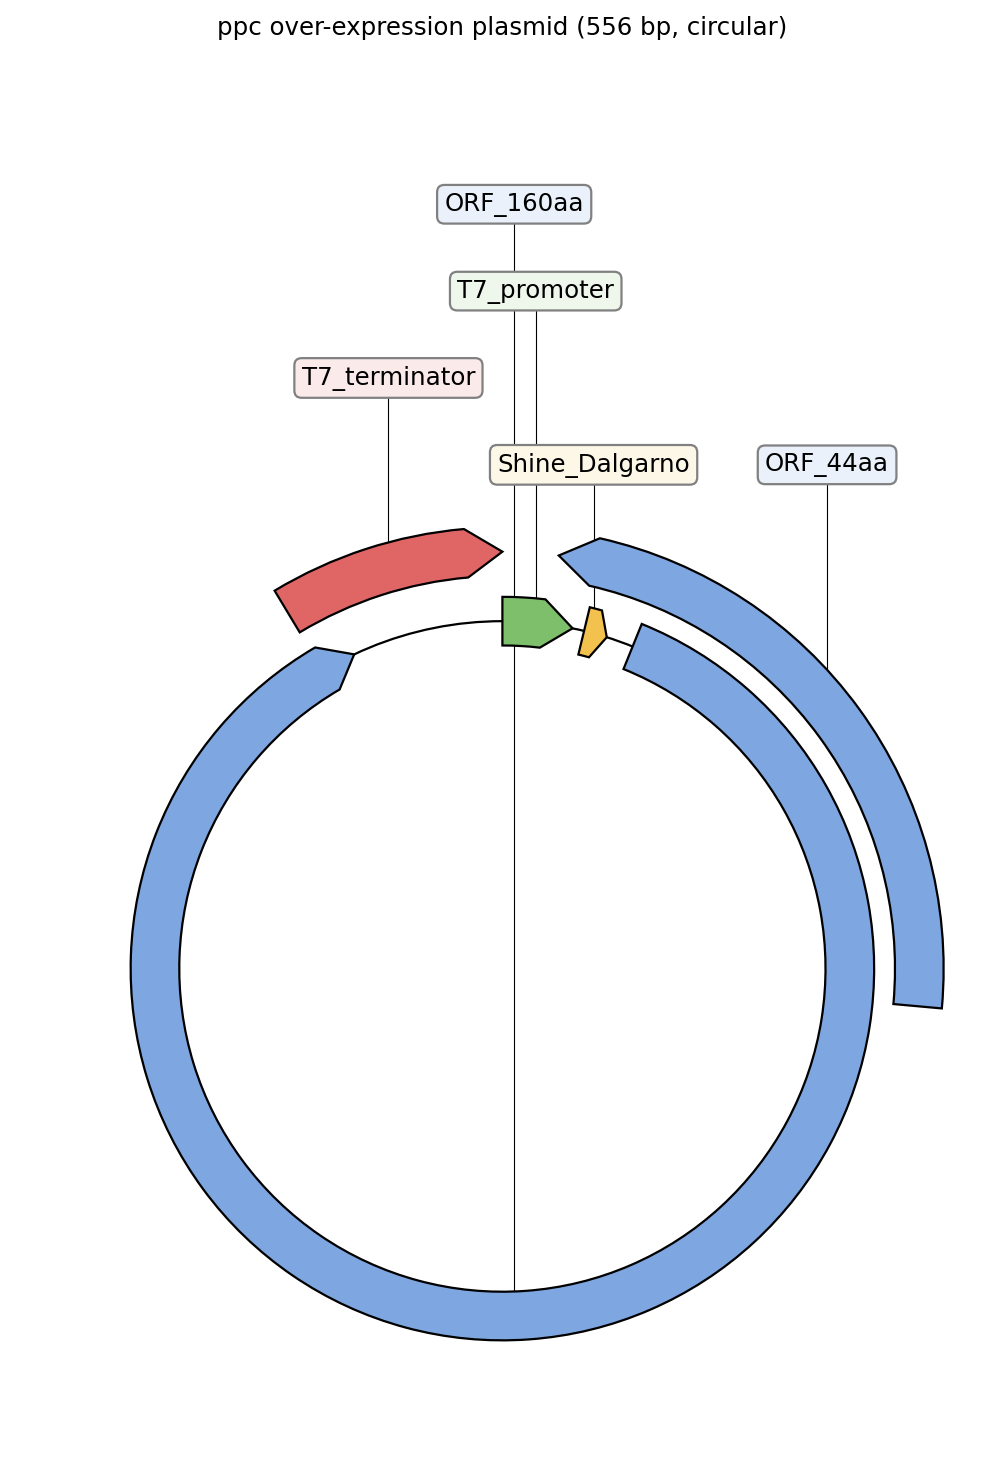

In [8]:
ppc_dna = ov.synbio.codon_optimize(PPC, host='e_coli').sequence
# assemble a ppc over-expression cassette: T7 promoter + RBS + gene + T7 terminator
cassette = ('TAATACGACTCACTATAGG' + 'AAAGGAGGACAACAT' + ppc_dna
            + 'CTAGCATAACCCCTTGGGGCCTCTAAACGGGTCTTGAGGGGTTTTTTG')
print('expression cassette:', len(cassette), 'bp')
ov.synbio.view_construct(cassette, circular=True, title='ppc over-expression plasmid')
None

cloning primers: PrimerPair(product=134bp, Tm=60.0/60.0, L=CCATTAAAGATGCGCTGGGC, R=ATCGTTGCTCAGGTTCTGCA)


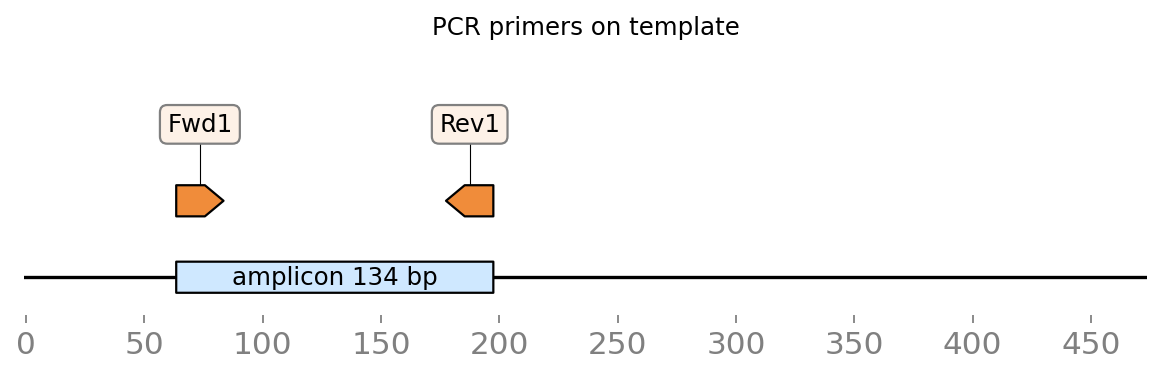

In [9]:
# PCR primers to clone the ppc gene — shown as binding arrows on the template
primers = ov.synbio.design_primers(ppc_dna)
print('cloning primers:', primers[0])
ov.synbio.view_primers(ppc_dna, primers[0])
None

## Summary

In one notebook we reproduced a real succinate cell-factory design: **diagnosed** that wild-type *E. coli* can't make succinate (production envelope), applied the real **anaerobic + knock-out-the-competition** strategy (`strain_design` FSEOF + exact OptKnock → PPC/FRD7 over-expression, PFL/lactate deletion), **verified** the ΔPFL strain couples succinate to growth, **checked the thermodynamics** of the reductive-TCA branch with real eQuilibrator ΔG + MDF, connected it to the **enzyme** carrying the flux (DLKcat k_cat → enzyme-constrained yield), and produced the **codon-optimised gene + primers** to build it — the full design-build cycle for a metabolic-engineering target, on a real GEM.